In [8]:
import sys
sys.path.append('/host/d/Github')
import os
import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import Osteosarcoma.functions_collection as ff
import Osteosarcoma.Build_lists.Build_list as Build_list
import Osteosarcoma.Data_processing as Data_processing

from __future__ import annotations

import os  # needed navigate the system to get the input data

import radiomics
from radiomics import (
    featureextractor,  # This module is used for interaction with pyradiomics
)

### step 1: voxel-based radiomics

In [3]:
# Instantiate the extractor
paramPath = '/host/d/Github/Osteosarcoma/radiomics_settings/MR_setting_voxel.yaml'
extractor = featureextractor.RadiomicsFeatureExtractor(paramPath)

print('Extraction parameters:\n\t', extractor.settings)
print('Enabled filters:\n\t', extractor.enabledImagetypes)
print('Enabled features:\n\t', extractor.enabledFeatures)

Extraction parameters:
	 {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': True, 'normalizeScale': 100, 'removeOutliers': None, 'resampledPixelSpacing': [1, 1, 1], 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'binWidth': 25, 'voxelArrayShift': 300, 'geometryTolerance': 0.0001, 'kernelRadius': 1, 'maskedKernel': True, 'initValue': 'nan', 'voxelBatch': 10000}
Enabled filters:
	 {'Original': {}}
Enabled features:
	 {'firstorder': ['10Percentile', '90Percentile', 'Energy', 'Mean', 'Median', 'Minimum', 'RootMeanSquared'], 'glcm': ['Autocorrelation', 'JointAverage'], 'gldm': ['DependenceEntropy', 'GrayLevelNonUniformity', 'HighGrayLevelEmphasis', 'LargeDependenceLowGrayLevelEmphasis', 'LowGrayLevelEmphasis', 'SmallDependenceHighGrayLevelEmphasis'], 'glrlm': ['GrayLevelNonUniformity', 'HighGrayLevelRunEmphasis', 'LongRunHighGrayLevelEmphas

### define patient list

In [4]:
patient_list_file = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set123.xlsx'
build = Build_list.Build(patient_list_file)
batch_list, patient_set_list, patient_index_list, label_list, image_path_list, mask_path_list = build.__build__()
print(f'Number of cases to process: {len(image_path_list)}')

Number of cases to process: 351


### extract voxel features

In [5]:
import SimpleITK as sitk


# ============================================================
# Voxel-based feature map extraction for traditional habitat
# ============================================================

data_path = "/host/e/D/Data/Habitats/Jishuitan/original_data"
save_root = "/host/d/projects/Habitats/radiomics/voxels"

for i in range(0, len(patient_index_list)):
    patient_set = patient_set_list[i]
    patient_index = patient_index_list[i]

    # check whether done, whether save original_ngtdm_Coarseness.nii.gz
    if os.path.exists(os.path.join(save_root, str(patient_set), str(patient_index), "feature_maps", "original_ngtdm_Coarseness.nii.gz")):
        print(f"Feature maps already exist for patient {patient_set}-{patient_index}. Skipping...")
        continue

    print("\n============================================================")
    print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

    img_p = os.path.join(
        data_path,
        str(patient_set),
        str(patient_index),
        "img.nii.gz",
    )

    # Whole-tumor mask, not patch mask.
    msk_p = os.path.join(
        data_path,
        str(patient_set),
        str(patient_index),
        "label.nii.gz",
    )

    save_folder = os.path.join(
        save_root,
        str(patient_set),
        str(patient_index),
    )

    feature_map_folder = os.path.join(save_folder, "feature_maps")
    ff.make_folder([
        os.path.dirname(save_folder),
        save_folder,
        feature_map_folder,
    ])

    feature_table_path = os.path.join(
        save_folder,
        "voxel_feature_table_Wang26.xlsx",
    )

    feature_table_csv_path = os.path.join(
        save_folder,
        "voxel_feature_table_Wang26.csv",
    )

    if os.path.exists(feature_table_path) or os.path.exists(feature_table_csv_path):
        print("  Voxel feature table already exists. Skipping...")
        continue

    if not os.path.isfile(img_p):
        raise FileNotFoundError(f"Image not found: {img_p}")

    if not os.path.isfile(msk_p):
        raise FileNotFoundError(f"Mask not found: {msk_p}")

    print("  Image:", img_p)
    print("  Mask:", msk_p)

    # ========================================================
    # 1. Voxel-based extraction
    # ========================================================

    result = extractor.execute(
        img_p,
        msk_p,
        voxelBased=True,
    )

    # Keep only feature maps.
    # In voxelBased mode, radiomics features are SimpleITK.Image objects.
    feature_maps = {
        k: v for k, v in result.items()
        if (not k.startswith("diagnostics_")) and isinstance(v, sitk.Image)
    }

    print("  Number of feature maps:", len(feature_maps))

    if len(feature_maps) == 0:
        raise RuntimeError(
            f"No voxel-based feature maps were extracted for patient {patient_set}-{patient_index}."
        )

    # ========================================================
    # 2. Save feature maps as NIfTI
    # ========================================================

    for feature_name, feature_img in feature_maps.items():
        feature_map_path = os.path.join(
            feature_map_folder,
            f"{feature_name}.nii.gz",
        )
        sitk.WriteImage(feature_img, feature_map_path)

    print("  Saved feature maps to:", feature_map_folder)


Feature maps already exist for patient set_1-1. Skipping...
Feature maps already exist for patient set_1-5. Skipping...
Feature maps already exist for patient set_1-7. Skipping...
Feature maps already exist for patient set_1-8. Skipping...
Feature maps already exist for patient set_1-11. Skipping...
Feature maps already exist for patient set_1-15. Skipping...
Feature maps already exist for patient set_1-18. Skipping...
Feature maps already exist for patient set_1-19. Skipping...
Feature maps already exist for patient set_1-20. Skipping...
Feature maps already exist for patient set_1-21. Skipping...
Feature maps already exist for patient set_1-22. Skipping...
Feature maps already exist for patient set_1-23. Skipping...
Feature maps already exist for patient set_1-24. Skipping...
Feature maps already exist for patient set_1-26. Skipping...
Feature maps already exist for patient set_1-28. Skipping...
Feature maps already exist for patient set_1-29. Skipping...
Feature maps already exist f

### Step2: normalize features and K-means to find out habitats

In [9]:
patient_list_file = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set123.xlsx'
build = Build_list.Build(patient_list_file)
batch_list, patient_set_list, patient_index_list, label_list, image_path_list, mask_path_list = build.__build__()
print(f'Number of cases to process: {len(image_path_list)}')

Number of cases to process: 351


In [10]:

import os
import glob
import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib.pyplot as plt

from skimage.measure import block_reduce
from scipy.ndimage import zoom
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# Settings
# ============================================================

voxel_radiomics_root = "/host/d/projects/Habitats/radiomics/voxels"
habitat_out_root = "/host/d/projects/Habitats/radiomics/habitats_individual"
data_path = "/host/e/D/Data/Habitats/Jishuitan/original_data"

K_candidates = [3,4, 5]
random_state = 0

# Tune this.
# (1, 1, 5): keep x/y, average every 5 slices in z
# (2, 2, 5): average 2x2 in-plane and 5 slices in z
downsample_block_size = (3,3,3)

n_init = 30

# Resume behavior: individual-K results for set_1/set_2 already exist under
# habitats_individual. When rerunning with set123, skip completed cases and
# only process newly added cases, such as set_3.
skip_existing_individual = True


for i in range(0,len(patient_index_list)):
    patient_set = patient_set_list[i]
    patient_index = patient_index_list[i]

    print("\n============================================================")
    print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

    # ========================================================
    # 1. Paths
    # ========================================================

    feature_map_dir = os.path.join(
        voxel_radiomics_root,
        str(patient_set),
        str(patient_index),
        "feature_maps",
    )

    save_folder = os.path.join(
        habitat_out_root,
        str(patient_set),
        str(patient_index),
    )

    os.makedirs(save_folder, exist_ok=True)

    sc_plot_path = os.path.join(save_folder, "silhouette_score_K3_K5.png")
    sc_table_path = os.path.join(save_folder, "silhouette_score_K3_K5.xlsx")
    summary_path = os.path.join(save_folder, "best_K_summary_downsampled.xlsx")
    habitats_downsampled_path = os.path.join(save_folder, "habitats_downsampled.nii.gz")
    habitats_path = os.path.join(save_folder, "habitats_space111.nii.gz")
    normalization_path = os.path.join(save_folder, "normalization_parameters_111.xlsx")

    if (
        skip_existing_individual
        and os.path.exists(sc_table_path)
        and os.path.exists(summary_path)
        and os.path.exists(habitats_downsampled_path)
        and os.path.exists(habitats_path)
    ):
        print("  Existing individual-K habitat files found. Skipping.")
        continue

    if not os.path.isdir(feature_map_dir):
        raise FileNotFoundError(f"Feature map folder not found: {feature_map_dir}")

    feature_map_paths = sorted(glob.glob(os.path.join(feature_map_dir, "*.nii.gz")))

    if len(feature_map_paths) == 0:
        raise RuntimeError(f"No feature maps found in: {feature_map_dir}")

    print("  Number of feature maps:", len(feature_map_paths))

    # ========================================================
    # 2. Load [1,1,1] feature maps
    # ========================================================

    feature_names = []
    feature_arrays = []

    reference_nii = nb.load(feature_map_paths[0])
    reference_shape = reference_nii.shape
    reference_affine = reference_nii.affine
    reference_header = reference_nii.header

    for feature_map_path in feature_map_paths:
        feature_name = os.path.basename(feature_map_path).replace(".nii.gz", "")

        feature_nii = nb.load(feature_map_path)
        feature_arr = feature_nii.get_fdata().astype(np.float32)

        if feature_arr.shape != reference_shape:
            raise ValueError(
                f"Shape mismatch for {feature_name}: "
                f"feature shape={feature_arr.shape}, reference shape={reference_shape}"
            )

        feature_names.append(feature_name)
        feature_arrays.append(feature_arr)

    feature_stack_111 = np.stack(feature_arrays, axis=-1)

    print("  Feature stack [1,1,1] shape:", feature_stack_111.shape)

    # ========================================================
    # 3. Identify tumor/foreground voxels in [1,1,1]
    # ========================================================

    # Background = all feature values are 0 at this voxel.
    # Foreground/tumor candidate = NOT all feature values are 0.
    all_zero_111 = np.all(feature_stack_111 == 0, axis=-1)
    all_nan_111 = np.all(np.isnan(feature_stack_111), axis=-1)

    foreground_111 = (~all_zero_111) & (~all_nan_111)

    X_111_raw = feature_stack_111[foreground_111, :]

    # print("  Candidate foreground voxels [1,1,1]:", X_111_raw.shape[0])

    valid_voxel_mask_111 = np.all(np.isfinite(X_111_raw), axis=1)

    n_invalid_111 = int((~valid_voxel_mask_111).sum())
    if n_invalid_111 > 0:
        print("  Removing invalid foreground voxels:", n_invalid_111)

    X_111_valid = X_111_raw[valid_voxel_mask_111, :]

    if X_111_valid.shape[0] == 0:
        raise RuntimeError("No valid foreground voxels left after removing NaN/Inf.")

    # print("  Valid foreground voxels [1,1,1]:", X_111_valid.shape[0])

    # ========================================================
    # 4. Remove constant features before normalization
    # ========================================================

    feature_std = X_111_valid.std(axis=0)
    nonconstant_feature_mask = feature_std > 0

    kept_feature_names = [
        feature_names[j]
        for j in range(len(feature_names))
        if nonconstant_feature_mask[j]
    ]

    removed_features = [
        feature_names[j]
        for j in range(len(feature_names))
        if not nonconstant_feature_mask[j]
    ]

    if len(removed_features) > 0:
        print("  Removing constant features:")
        for f in removed_features:
            print("   ", f)

    X_111_valid = X_111_valid[:, nonconstant_feature_mask]

    if X_111_valid.shape[1] == 0:
        raise RuntimeError("No nonconstant features left for clustering.")

    # print("  Feature matrix after feature QC:", X_111_valid.shape)

    # ========================================================
    # 5. Per-case z-score normalization in [1,1,1] foreground voxels
    # ========================================================

    scaler = StandardScaler()
    X_111_norm = scaler.fit_transform(X_111_valid)

    # print("  Normalized matrix [1,1,1] shape:", X_111_norm.shape)
    # print("  First 5 normalized means:", np.mean(X_111_norm, axis=0)[:5])
    # print("  First 5 normalized stds:", np.std(X_111_norm, axis=0)[:5])

    norm_df = pd.DataFrame({
        "feature_name": kept_feature_names,
        "mean": scaler.mean_,
        "scale_std": scaler.scale_,
    })

    norm_df.to_excel(normalization_path, index=False)
    # print("  Saved normalization parameters:", normalization_path)

    # ========================================================
    # 6. Write normalized foreground values back to 4D image space
    # ========================================================

    feature_stack_111_norm = np.zeros(
        reference_shape + (len(kept_feature_names),),
        dtype=np.float32,
    )

    foreground_coords_111 = np.where(foreground_111)

    valid_coords_111 = (
        foreground_coords_111[0][valid_voxel_mask_111],
        foreground_coords_111[1][valid_voxel_mask_111],
        foreground_coords_111[2][valid_voxel_mask_111],
    )

    feature_stack_111_norm[valid_coords_111] = X_111_norm.astype(np.float32)

    # ========================================================
    # 7. Downsample normalized feature maps by block mean
    # ========================================================

    feature_down_list = []

    for j, feature_name in enumerate(kept_feature_names):
        # print(f"  Downsampling feature {j + 1}/{len(kept_feature_names)}:", feature_name)

        feature_down_j = block_reduce(
            feature_stack_111_norm[..., j],
            block_size=downsample_block_size,
            func=np.mean,
            cval=0,
        )

        feature_down_list.append(feature_down_j.astype(np.float32))

    feature_stack_down = np.stack(feature_down_list, axis=-1)

    print("  Downsampled feature stack shape:", feature_stack_down.shape)

    # ========================================================
    # 8. Identify foreground directly from downsampled feature maps
    # ========================================================

    # Background after downsampling = all downsampled features are 0.
    # Foreground after downsampling = NOT all downsampled features are 0.
    all_zero_down = np.all(feature_stack_down == 0, axis=-1)
    all_nan_down = np.all(np.isnan(feature_stack_down), axis=-1)

    foreground_down = (~all_zero_down) & (~all_nan_down)

    # print("  Downsampled foreground voxels:", int(foreground_down.sum()))

    if int(foreground_down.sum()) == 0:
        raise RuntimeError("No foreground voxels found in downsampled feature maps.")

    # ========================================================
    # 9. Build K-means matrix from downsampled nonzero voxels
    # ========================================================

    X_down = feature_stack_down[foreground_down, :]

    valid_down_mask = np.all(np.isfinite(X_down), axis=1)

    n_invalid_down = int((~valid_down_mask).sum())
    if n_invalid_down > 0:
        print("  Removing invalid downsampled foreground voxels:", n_invalid_down)

    X_down_valid = X_down[valid_down_mask, :]

    if X_down_valid.shape[0] == 0:
        raise RuntimeError("No valid downsampled voxels left for K-means.")

    print("  K-means input matrix shape:", X_down_valid.shape)

    # ========================================================
    # 10. K-means for K=3,4,5 and calculate SC
    # ========================================================

    sc_rows = []
    kmeans_models = {}

    for K in K_candidates:
        print(f"  Running K-means with K={K}")

        kmeans = KMeans(
            n_clusters=K,
            random_state=random_state,
            n_init=n_init,
            max_iter=300,
        )

        cluster_labels = kmeans.fit_predict(X_down_valid)

        print(f"    Calculating silhouette score for K={K}")
        sc = silhouette_score(X_down_valid, cluster_labels)

        print(f"    Silhouette score: {sc:.4f}")

        sc_rows.append({
            "K": K,
            "silhouette_score": sc,
            "n_voxels_for_kmeans": X_down_valid.shape[0],
            "n_features_used": X_down_valid.shape[1],
            "downsample_block_x": downsample_block_size[0],
            "downsample_block_y": downsample_block_size[1],
            "downsample_block_z": downsample_block_size[2],
        })

        kmeans_models[K] = {
            "model": kmeans,
            "labels": cluster_labels,
            "silhouette_score": sc,
        }

    sc_df = pd.DataFrame(sc_rows)
    sc_df.to_excel(sc_table_path, index=False)

    # print("  Saved SC table:", sc_table_path)

    # ========================================================
    # 11. Save SC plot
    # ========================================================

    plt.figure(figsize=(5, 4))
    plt.plot(
        sc_df["K"],
        sc_df["silhouette_score"],
        marker="o",
        linewidth=2,
    )

    plt.xticks(K_candidates)
    plt.xlabel("Number of clusters K")
    plt.ylabel("Silhouette coefficient")
    plt.title(f"SC for K-means: {patient_set}-{patient_index}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(sc_plot_path, dpi=300)
    plt.close()

    # print("  Saved SC plot:", sc_plot_path)

    # ========================================================
    # 12. Select best K
    # ========================================================

    best_row = sc_df.loc[sc_df["silhouette_score"].idxmax()]
    best_K = int(best_row["K"])
    best_SC = float(best_row["silhouette_score"])

    print("  Best K:", best_K)
    print("  Best SC:", best_SC)

    best_labels_valid = kmeans_models[best_K]["labels"]

    # ========================================================
    # 13. Map labels back to downsampled image space
    # ========================================================

    habitats_downsampled = np.zeros(foreground_down.shape, dtype=np.uint8)

    foreground_down_coords = np.where(foreground_down)

    valid_down_coords = (
        foreground_down_coords[0][valid_down_mask],
        foreground_down_coords[1][valid_down_mask],
        foreground_down_coords[2][valid_down_mask],
    )

    # 0 = background or invalid voxel
    # 1..best_K = habitat labels
    habitats_downsampled[valid_down_coords] = best_labels_valid.astype(np.uint8) + 1

    nb.save(
        nb.Nifti1Image(
            habitats_downsampled.astype(np.uint8),
            reference_affine,
            reference_header,
        ),
        habitats_downsampled_path,
    )

    # print("  Saved habitats_downsampled:", habitats_downsampled_path)

    # ========================================================
    # 14. Save summary
    # ========================================================

    summary_df = pd.DataFrame([{
        "Patient_set": patient_set,
        "Patient_index": patient_index,
        "best_K": best_K,
        "best_silhouette_score": best_SC,
        "n_foreground_111_candidate": int(X_111_raw.shape[0]),
        "n_foreground_111_valid": int(X_111_norm.shape[0]),
        "n_foreground_downsampled": int(foreground_down.sum()),
        "n_foreground_downsampled_valid": int(X_down_valid.shape[0]),
        "n_features_raw": len(feature_names),
        "n_features_used": len(kept_feature_names),
        "downsample_block_size": str(downsample_block_size),
        "random_state": random_state,
        "n_init": n_init,
    }])

    summary_df.to_excel(summary_path, index=False)
    # print("  Saved summary:", summary_path)

    # print("Done downsampled habitat clustering:", patient_set, patient_index)


        # ========================================================
    # 15. Upsample habitats_downsampled back to [1,1,1] feature-map space
    # ========================================================

    habitats_path = os.path.join(
        save_folder,
        "habitats_space111.nii.gz",
    )

    habitats_down_nii = nb.load(habitats_downsampled_path)
    habitats_down = habitats_down_nii.get_fdata().astype(np.uint8)

    target_shape = reference_shape  # feature-map [1,1,1] shape

    print("  habitats_downsampled shape:", habitats_down.shape)
    print("  target [1,1,1] feature-map shape:", target_shape)

    zoom_factors = (
        target_shape[0] / habitats_down.shape[0],
        target_shape[1] / habitats_down.shape[1],
        target_shape[2] / habitats_down.shape[2],
    )

    print("  zoom factors:", zoom_factors)

    habitats_zoomed = zoom(
        habitats_down,
        zoom=zoom_factors,
        order=0,
    ).astype(np.uint8)

    print("  zoomed habitat shape before crop/pad:", habitats_zoomed.shape)

    # ========================================================
    # 16. Crop or pad to exactly match feature-map [1,1,1] shape
    # ========================================================

    habitats_111 = np.zeros(target_shape, dtype=np.uint8)

    copy_shape = (
        min(target_shape[0], habitats_zoomed.shape[0]),
        min(target_shape[1], habitats_zoomed.shape[1]),
        min(target_shape[2], habitats_zoomed.shape[2]),
    )

    habitats_111[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ] = habitats_zoomed[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ]

    print("  habitat shape after crop/pad:", habitats_111.shape)

    # ========================================================
    # 17. Restrict habitats to [1,1,1] foreground from feature maps
    # ========================================================

    n_before_clip = int(np.sum(habitats_111 > 0))

    # foreground_111 was created from the original [1,1,1] feature maps:
    # foreground = NOT all feature values are 0.
    habitats_111[~foreground_111] = 0

    n_after_clip = int(np.sum(habitats_111 > 0))

    print("  habitat voxels before foreground clipping:", n_before_clip)
    print("  habitat voxels after foreground clipping:", n_after_clip)
    print("  removed outside-feature-foreground voxels:", n_before_clip - n_after_clip)

    # ========================================================
    # 18. Save multiclass habitat map in [1,1,1] feature-map space
    # ========================================================

    habitat_nii = nb.Nifti1Image(
        habitats_111.astype(np.uint8),
        affine=reference_affine,
        header=reference_header,
    )

    nb.save(habitat_nii, habitats_path)

    print("  Saved multiclass habitats [1,1,1]:", habitats_path)

   


Processing patient set: set_1 patient index: 1  i is  0
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 5  i is  1
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 7  i is  2
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 8  i is  3
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 11  i is  4
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 15  i is  5
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 18  i is  6
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 19  i is  7
  Existing individual-K habitat files found. Skipping.

Processing patient set: set_1 patient index: 20  i is  8
  Existing individual-K habitat files foun

### Step2_alternative: cohort-level K selection curves using silhouette coefficient and CH index

This alternative follows the paper-style strategy: normalize each case, test K=2..9, calculate silhouette coefficient and Calinski-Harabasz index per case, then plot cohort-level mean curves. No habitat masks are generated in this step.


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib.pyplot as plt

from skimage.measure import block_reduce
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# Step2_alternative settings
# Paper-style cohort/training-level K selection curve.
# This cell only calculates scores and saves plots; it does not
# generate habitat masks.
# ============================================================

voxel_radiomics_root = "/host/d/projects/Habitats/radiomics/voxels"
habitat_out_root = "/host/d/projects/Habitats/radiomics/habitats"

K_candidates_alt = list(range(2, 10))
random_state = 0
n_init = 30

downsample_block_size = (3, 3, 3)

# Silhouette calculation can be very slow for large voxel matrices.
# Set to None for exact SC on all downsampled voxels.
silhouette_sample_size = None

# Run only the first N cases for cohort-level K selection.
# Increase this later if you want to add more cases; existing case/K scores
# will be reused from case_score_path.
max_cases_for_k_selection = 110

alt_out_folder = habitat_out_root
os.makedirs(alt_out_folder, exist_ok=True)

case_score_path = os.path.join(
    alt_out_folder,
    "case_level_K2_K9_silhouette_CH_scores.xlsx",
)
cohort_score_path = os.path.join(
    alt_out_folder,
    "cohort_mean_K2_K9_silhouette_CH_scores.xlsx",
)
sc_plot_path = os.path.join(
    alt_out_folder,
    "cohort_mean_silhouette_K2_K9.png",
)
ch_plot_path = os.path.join(
    alt_out_folder,
    "cohort_mean_CH_K2_K9.png",
)

# If the cohort-level mean score table already exists, the global K curve
# has already been generated. Do not rerun this expensive block just
# because set_3 was added.
skip_existing_cohort_K_scores = True


def build_downsampled_normalized_matrix_for_case(feature_map_dir):
    """Return X_down_valid after per-case foreground z-score normalization."""

    if not os.path.isdir(feature_map_dir):
        raise FileNotFoundError(f"Feature map folder not found: {feature_map_dir}")

    feature_map_paths = sorted(glob.glob(os.path.join(feature_map_dir, "*.nii.gz")))
    if len(feature_map_paths) == 0:
        raise RuntimeError(f"No feature maps found in: {feature_map_dir}")

    feature_names = []
    feature_arrays = []

    reference_nii = nb.load(feature_map_paths[0])
    reference_shape = reference_nii.shape

    for feature_map_path in feature_map_paths:
        feature_name = os.path.basename(feature_map_path).replace(".nii.gz", "")
        feature_nii = nb.load(feature_map_path)
        feature_arr = feature_nii.get_fdata().astype(np.float32)

        if feature_arr.shape != reference_shape:
            raise ValueError(
                f"Shape mismatch for {feature_name}: "
                f"feature shape={feature_arr.shape}, reference shape={reference_shape}"
            )

        feature_names.append(feature_name)
        feature_arrays.append(feature_arr)

    feature_stack_111 = np.stack(feature_arrays, axis=-1)

    # Background = all feature values are 0 at this voxel.
    # Foreground/tumor candidate = NOT all feature values are 0.
    all_zero_111 = np.all(feature_stack_111 == 0, axis=-1)
    all_nan_111 = np.all(np.isnan(feature_stack_111), axis=-1)
    foreground_111 = (~all_zero_111) & (~all_nan_111)

    X_111_raw = feature_stack_111[foreground_111, :]
    valid_voxel_mask_111 = np.all(np.isfinite(X_111_raw), axis=1)
    X_111_valid = X_111_raw[valid_voxel_mask_111, :]

    if X_111_valid.shape[0] == 0:
        raise RuntimeError("No valid foreground voxels left after removing NaN/Inf.")

    # Remove constant features before normalization.
    feature_std = X_111_valid.std(axis=0)
    nonconstant_feature_mask = feature_std > 0
    X_111_valid = X_111_valid[:, nonconstant_feature_mask]

    if X_111_valid.shape[1] == 0:
        raise RuntimeError("No nonconstant features left for clustering.")

    # Per-case z-score normalization in [1,1,1] foreground voxels.
    scaler = StandardScaler()
    X_111_norm = scaler.fit_transform(X_111_valid)

    # Write normalized foreground values back to 4D image space.
    feature_stack_111_norm = np.zeros(
        reference_shape + (X_111_norm.shape[1],),
        dtype=np.float32,
    )

    foreground_coords_111 = np.where(foreground_111)
    valid_coords_111 = (
        foreground_coords_111[0][valid_voxel_mask_111],
        foreground_coords_111[1][valid_voxel_mask_111],
        foreground_coords_111[2][valid_voxel_mask_111],
    )
    feature_stack_111_norm[valid_coords_111] = X_111_norm.astype(np.float32)

    # Downsample normalized feature maps by block mean.
    feature_down_list = []
    for j in range(X_111_norm.shape[1]):
        feature_down_j = block_reduce(
            feature_stack_111_norm[..., j],
            block_size=downsample_block_size,
            func=np.mean,
            cval=0,
        )
        feature_down_list.append(feature_down_j.astype(np.float32))

    feature_stack_down = np.stack(feature_down_list, axis=-1)

    # Background after downsampling = all downsampled features are 0.
    all_zero_down = np.all(feature_stack_down == 0, axis=-1)
    all_nan_down = np.all(np.isnan(feature_stack_down), axis=-1)
    foreground_down = (~all_zero_down) & (~all_nan_down)

    if int(foreground_down.sum()) == 0:
        raise RuntimeError("No foreground voxels found in downsampled feature maps.")

    X_down = feature_stack_down[foreground_down, :]
    valid_down_mask = np.all(np.isfinite(X_down), axis=1)
    X_down_valid = X_down[valid_down_mask, :]

    if X_down_valid.shape[0] == 0:
        raise RuntimeError("No valid downsampled voxels left for K-means.")

    return X_down_valid


def save_current_K_selection_outputs(case_score_rows):
    case_score_df = pd.DataFrame(case_score_rows)
    case_score_df.to_excel(case_score_path, index=False)

    valid_score_df = case_score_df[case_score_df["status"] == "ok"].copy()
    if valid_score_df.shape[0] == 0:
        return

    valid_score_df["K"] = valid_score_df["K"].astype(int)

    cohort_score_df = (
        valid_score_df
        .groupby("K", as_index=False)
        .agg(
            mean_silhouette_score=("silhouette_score", "mean"),
            std_silhouette_score=("silhouette_score", "std"),
            mean_calinski_harabasz_score=("calinski_harabasz_score", "mean"),
            std_calinski_harabasz_score=("calinski_harabasz_score", "std"),
            n_cases=("Patient_index", "count"),
            mean_n_voxels_for_kmeans=("n_voxels_for_kmeans", "mean"),
            mean_n_features_used=("n_features_used", "mean"),
        )
    )
    cohort_score_df.to_excel(cohort_score_path, index=False)

    # Plot 1: cohort-level mean silhouette coefficient curve.
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        cohort_score_df["K"],
        cohort_score_df["mean_silhouette_score"],
        yerr=cohort_score_df["std_silhouette_score"],
        marker="o",
        linewidth=2,
        capsize=4,
    )
    plt.xticks(K_candidates_alt)
    plt.xlabel("Number of clusters K")
    plt.ylabel("Mean silhouette coefficient")
    plt.title("Cohort-level silhouette coefficient for K-means")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(sc_plot_path, dpi=300)
    plt.close()

    # Plot 2: cohort-level mean Calinski-Harabasz index curve.
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        cohort_score_df["K"],
        cohort_score_df["mean_calinski_harabasz_score"],
        yerr=cohort_score_df["std_calinski_harabasz_score"],
        marker="o",
        linewidth=2,
        capsize=4,
    )
    plt.xticks(K_candidates_alt)
    plt.xlabel("Number of clusters K")
    plt.ylabel("Mean Calinski-Harabasz index")
    plt.title("Cohort-level CH index for K-means")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ch_plot_path, dpi=300)
    plt.close()


if skip_existing_cohort_K_scores and os.path.exists(cohort_score_path):
    print("Existing cohort-level K score file found. Skipping Step2_alternative recalculation:")
    print(" ", cohort_score_path)
    if os.path.exists(case_score_path):
        print("Existing case-level K score file:", case_score_path)
    print("Existing SC plot:", sc_plot_path)
    print("Existing CH plot:", ch_plot_path)
else:
    if os.path.exists(case_score_path):
        existing_case_score_df = pd.read_excel(case_score_path)
        case_score_rows = existing_case_score_df.to_dict("records")
        print("Loaded existing case-level K scores:", case_score_path)
        print("  Existing rows:", len(case_score_rows))
    else:
        case_score_rows = []

    completed_case_k = set()
    for row in case_score_rows:
        if pd.isna(row.get("K", np.nan)):
            continue
        if row.get("status") not in ["ok", "failed"]:
            continue
        completed_case_k.add((str(row["Patient_set"]), str(row["Patient_index"]), int(row["K"])))

    n_cases_to_run = min(max_cases_for_k_selection, len(patient_index_list))
    case_indices_to_process = list(range(0, n_cases_to_run))

    print("Cases requested for Step2_alternative:", n_cases_to_run)
    print("K candidates:", K_candidates_alt)
    print("Already completed case/K rows:", len(completed_case_k))

    for i in case_indices_to_process:
        patient_set = patient_set_list[i]
        patient_index = patient_index_list[i]
        patient_key = (str(patient_set), str(patient_index))

        missing_K = [
            K for K in K_candidates_alt
            if (patient_key[0], patient_key[1], K) not in completed_case_k
        ]

        if len(missing_K) == 0:
            print("\n============================================================")
            print("Step2_alternative already complete, skipping:", patient_set, patient_index, "i =", i)
            continue

        print("\n============================================================")
        print("Step2_alternative processing:", patient_set, patient_index, "i =", i)
        print("  Missing K:", missing_K)

        feature_map_dir = os.path.join(
            voxel_radiomics_root,
            str(patient_set),
            str(patient_index),
            "feature_maps",
        )

        try:
            X_down_valid = build_downsampled_normalized_matrix_for_case(feature_map_dir)
        except Exception as e:
            print("  Skipping case because of error:", repr(e))
            case_score_rows.append({
                "Patient_set": patient_set,
                "Patient_index": patient_index,
                "K": np.nan,
                "silhouette_score": np.nan,
                "calinski_harabasz_score": np.nan,
                "n_voxels_for_kmeans": np.nan,
                "n_features_used": np.nan,
                "status": "failed",
                "error": repr(e),
            })
            save_current_K_selection_outputs(case_score_rows)
            continue

        print("  K-means input matrix shape:", X_down_valid.shape)

        for K in missing_K:
            if X_down_valid.shape[0] <= K:
                print(f"  Skipping K={K}: n_voxels <= K")
                case_score_rows.append({
                    "Patient_set": patient_set,
                    "Patient_index": patient_index,
                    "K": K,
                    "silhouette_score": np.nan,
                    "calinski_harabasz_score": np.nan,
                    "n_voxels_for_kmeans": X_down_valid.shape[0],
                    "n_features_used": X_down_valid.shape[1],
                    "status": "failed",
                    "error": "n_voxels <= K",
                })
                completed_case_k.add((patient_key[0], patient_key[1], K))
                save_current_K_selection_outputs(case_score_rows)
                continue

            print(f"  Running K-means with K={K}")

            kmeans = KMeans(
                n_clusters=K,
                random_state=random_state,
                n_init=n_init,
                max_iter=300,
            )
            cluster_labels = kmeans.fit_predict(X_down_valid)

            unique_labels = np.unique(cluster_labels)
            if len(unique_labels) < 2:
                sc = np.nan
                ch = np.nan
                status = "failed"
                error = "less than 2 clusters after K-means"
            else:
                if silhouette_sample_size is None:
                    sc = silhouette_score(X_down_valid, cluster_labels)
                else:
                    sc = silhouette_score(
                        X_down_valid,
                        cluster_labels,
                        sample_size=min(silhouette_sample_size, X_down_valid.shape[0]),
                        random_state=random_state,
                    )
                ch = calinski_harabasz_score(X_down_valid, cluster_labels)
                status = "ok"
                error = ""

            print(f"    SC={sc:.4f}, CH={ch:.4f}")

            case_score_rows.append({
                "Patient_set": patient_set,
                "Patient_index": patient_index,
                "K": K,
                "silhouette_score": sc,
                "calinski_harabasz_score": ch,
                "n_voxels_for_kmeans": X_down_valid.shape[0],
                "n_features_used": X_down_valid.shape[1],
                "downsample_block_size": str(downsample_block_size),
                "silhouette_sample_size": silhouette_sample_size,
                "random_state": random_state,
                "n_init": n_init,
                "status": status,
                "error": error,
            })
            completed_case_k.add((patient_key[0], patient_key[1], K))
            save_current_K_selection_outputs(case_score_rows)


    save_current_K_selection_outputs(case_score_rows)
    print("\nSaved case-level K scores:", case_score_path)
    print("Saved cohort mean K scores:", cohort_score_path)
    print("Saved SC plot:", sc_plot_path)
    print("Saved CH plot:", ch_plot_path)
    print("\nStep2_alternative finished. Please inspect the two plots and choose the final K manually.")


Cases requested for Step2_alternative: 110
K candidates: [2, 3, 4, 5, 6, 7, 8, 9]
Already completed case/K rows: 0

Step2_alternative processing: set_1 1 i = 0
  Missing K: [2, 3, 4, 5, 6, 7, 8, 9]
  K-means input matrix shape: (32674, 25)
  Running K-means with K=2
    SC=0.3702, CH=22895.0523


/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


  Running K-means with K=3
    SC=0.3483, CH=21616.1221


/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


  Running K-means with K=4
    SC=0.3143, CH=20319.2166


...

  Running K-means with K=8
    SC=0.2845, CH=17680.0367


/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


  Running K-means with K=9
    SC=0.2741, CH=17114.5054


/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])



Step2_alternative processing: set_1 5 i = 1
  Missing K: [2, 3, 4, 5, 6, 7, 8, 9]
  K-means input matrix shape: (5967, 25)
  Running K-means with K=2
    SC=0.4008, CH=3854.8111
  Running K-means with K=3
    SC=0.4040, CH=4129.9400
  Running K-means with K=4
    SC=0.3842, CH=3989.4046
  Running K-means with K=5
    SC=0.3700, CH=3793.8176
  Running K-means with K=6
    SC=0.3422, CH=3779.8211
  Running K-means with K=7
    SC=0.3153, CH=3664.5957
  Running K-means with K=8
    SC=0.2991, CH=3566.3716
  Running K-means with K=9
    SC=0.2938, CH=3490.9350

Step2_alternative processing: set_1 7 i = 2
  Missing K: [2, 3, 4, 5, 6, 7, 8, 9]
  K-means input matrix shape: (11113, 25)
  Running K-means with K=2
    SC=0.3692, CH=7204.5392
  Running K-means with K=3
    SC=0.3966, CH=6777.3186
  Running K-means with K=4
    SC=0.3181, CH=6661.0843
  Running K-means with K=5
    SC=0.3250, CH=6723.2809
  Running K-means with K=6
    SC=0.2696, CH=6187.6916
  Running K-means with K=7
    SC=0.

#### Make plots

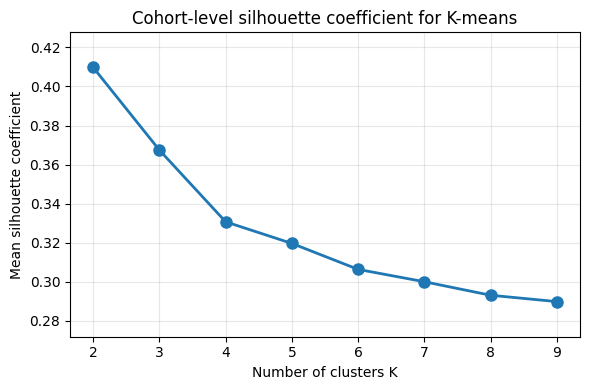

Saved SC plot: /host/d/projects/Habitats/radiomics/habitats/cohort_mean_silhouette_K2_K9_no_errorbar.png


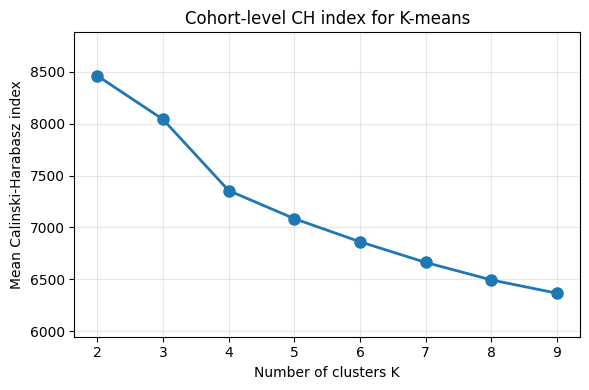

Saved CH plot: /host/d/projects/Habitats/radiomics/habitats/cohort_mean_CH_K2_K9_no_errorbar.png


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================

habitat_out_root = "/host/d/projects/Habitats/radiomics/habitats"

cohort_score_path = os.path.join(
    habitat_out_root,
    "cohort_mean_K2_K9_silhouette_CH_scores.xlsx",
)

sc_plot_path = os.path.join(
    habitat_out_root,
    "cohort_mean_silhouette_K2_K9_no_errorbar.png",
)

ch_plot_path = os.path.join(
    habitat_out_root,
    "cohort_mean_CH_K2_K9_no_errorbar.png",
)

# ============================================================
# Load cohort-level table
# ============================================================

cohort_score_df = pd.read_excel(cohort_score_path)
cohort_score_df = cohort_score_df.sort_values("K").reset_index(drop=True)

K_list = cohort_score_df["K"].astype(int)

# ============================================================
# Plot 1: silhouette coefficient
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(
    K_list,
    cohort_score_df["mean_silhouette_score"],
    marker="o",
    linewidth=2,
    markersize=8,
)

plt.xticks(K_list)
plt.xlabel("Number of clusters K")
plt.ylabel("Mean silhouette coefficient")
plt.title("Cohort-level silhouette coefficient for K-means")
plt.grid(True, alpha=0.3)

# Let the y-axis follow the actual data range with a small margin
sc_min = cohort_score_df["mean_silhouette_score"].min()
sc_max = cohort_score_df["mean_silhouette_score"].max()
sc_margin = (sc_max - sc_min) * 0.15
plt.ylim(sc_min - sc_margin, sc_max + sc_margin)

plt.tight_layout()
plt.savefig(sc_plot_path, dpi=300)
plt.show()
plt.close()

print("Saved SC plot:", sc_plot_path)

# ============================================================
# Plot 2: CH index
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(
    K_list,
    cohort_score_df["mean_calinski_harabasz_score"],
    marker="o",
    linewidth=2,
    markersize=8,
)

plt.xticks(K_list)
plt.xlabel("Number of clusters K")
plt.ylabel("Mean Calinski-Harabasz index")
plt.title("Cohort-level CH index for K-means")
plt.grid(True, alpha=0.3)

# CH range is often visually too tall if it starts from 0.
# Use a tighter range around the actual mean values.
ch_min = cohort_score_df["mean_calinski_harabasz_score"].min()
ch_max = cohort_score_df["mean_calinski_harabasz_score"].max()
ch_margin = (ch_max - ch_min) * 0.20
plt.ylim(ch_min - ch_margin, ch_max + ch_margin)

plt.tight_layout()
plt.savefig(ch_plot_path, dpi=300)
plt.show()
plt.close()

print("Saved CH plot:", ch_plot_path)

### Step2_fixedK_apply_to_all_cases: apply manually selected K to every case

Set `fixed_K` after inspecting the Step2_alternative SC/CH curves. This block applies the same K to all cases and saves the same downsampled and [1,1,1] habitat files used by the later back-projection step.


In [11]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nb
import matplotlib.pyplot as plt

from skimage.measure import block_reduce
from scipy.ndimage import zoom
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ============================================================
# Settings: apply manually selected K to all cases
# ============================================================

voxel_radiomics_root = "/host/d/projects/Habitats/radiomics/voxels"
habitat_out_root = "/host/d/projects/Habitats/radiomics/habitats"  # global fixed-K branch

fixed_K = 4  # Change this manually after checking the Step2_alternative plots.
random_state = 0
n_init = 30
max_iter = 300

downsample_block_size = (3, 3, 3)
skip_existing_same_K = True


def prepare_case_features_for_fixed_K(feature_map_dir):
    """Normalize [1,1,1] feature maps and build the downsampled K-means matrix."""

    if not os.path.isdir(feature_map_dir):
        raise FileNotFoundError(f"Feature map folder not found: {feature_map_dir}")

    feature_map_paths = sorted(glob.glob(os.path.join(feature_map_dir, "*.nii.gz")))
    if len(feature_map_paths) == 0:
        raise RuntimeError(f"No feature maps found in: {feature_map_dir}")

    feature_names = []
    feature_arrays = []

    reference_nii = nb.load(feature_map_paths[0])
    reference_shape = reference_nii.shape
    reference_affine = reference_nii.affine
    reference_header = reference_nii.header

    for feature_map_path in feature_map_paths:
        feature_name = os.path.basename(feature_map_path).replace(".nii.gz", "")
        feature_nii = nb.load(feature_map_path)
        feature_arr = feature_nii.get_fdata().astype(np.float32)

        if feature_arr.shape != reference_shape:
            raise ValueError(
                f"Shape mismatch for {feature_name}: "
                f"feature shape={feature_arr.shape}, reference shape={reference_shape}"
            )

        feature_names.append(feature_name)
        feature_arrays.append(feature_arr)

    feature_stack_111 = np.stack(feature_arrays, axis=-1)

    all_zero_111 = np.all(feature_stack_111 == 0, axis=-1)
    all_nan_111 = np.all(np.isnan(feature_stack_111), axis=-1)
    foreground_111 = (~all_zero_111) & (~all_nan_111)

    X_111_raw = feature_stack_111[foreground_111, :]
    valid_voxel_mask_111 = np.all(np.isfinite(X_111_raw), axis=1)
    X_111_valid = X_111_raw[valid_voxel_mask_111, :]

    if X_111_valid.shape[0] == 0:
        raise RuntimeError("No valid foreground voxels left after removing NaN/Inf.")

    feature_std = X_111_valid.std(axis=0)
    nonconstant_feature_mask = feature_std > 0

    kept_feature_names = [
        feature_names[j]
        for j in range(len(feature_names))
        if nonconstant_feature_mask[j]
    ]
    removed_features = [
        feature_names[j]
        for j in range(len(feature_names))
        if not nonconstant_feature_mask[j]
    ]

    X_111_valid = X_111_valid[:, nonconstant_feature_mask]
    if X_111_valid.shape[1] == 0:
        raise RuntimeError("No nonconstant features left for clustering.")

    scaler = StandardScaler()
    X_111_norm = scaler.fit_transform(X_111_valid)

    feature_stack_111_norm = np.zeros(
        reference_shape + (len(kept_feature_names),),
        dtype=np.float32,
    )

    foreground_coords_111 = np.where(foreground_111)
    valid_coords_111 = (
        foreground_coords_111[0][valid_voxel_mask_111],
        foreground_coords_111[1][valid_voxel_mask_111],
        foreground_coords_111[2][valid_voxel_mask_111],
    )
    feature_stack_111_norm[valid_coords_111] = X_111_norm.astype(np.float32)

    feature_down_list = []
    for j in range(len(kept_feature_names)):
        feature_down_j = block_reduce(
            feature_stack_111_norm[..., j],
            block_size=downsample_block_size,
            func=np.mean,
            cval=0,
        )
        feature_down_list.append(feature_down_j.astype(np.float32))

    feature_stack_down = np.stack(feature_down_list, axis=-1)

    all_zero_down = np.all(feature_stack_down == 0, axis=-1)
    all_nan_down = np.all(np.isnan(feature_stack_down), axis=-1)
    foreground_down = (~all_zero_down) & (~all_nan_down)

    if int(foreground_down.sum()) == 0:
        raise RuntimeError("No foreground voxels found in downsampled feature maps.")

    X_down = feature_stack_down[foreground_down, :]
    valid_down_mask = np.all(np.isfinite(X_down), axis=1)
    X_down_valid = X_down[valid_down_mask, :]

    if X_down_valid.shape[0] == 0:
        raise RuntimeError("No valid downsampled voxels left for K-means.")

    return {
        "reference_shape": reference_shape,
        "reference_affine": reference_affine,
        "reference_header": reference_header,
        "foreground_111": foreground_111,
        "foreground_down": foreground_down,
        "valid_down_mask": valid_down_mask,
        "X_down_valid": X_down_valid,
        "X_111_raw": X_111_raw,
        "X_111_norm": X_111_norm,
        "kept_feature_names": kept_feature_names,
        "removed_features": removed_features,
        "scaler": scaler,
    }


for i in range(0, len(patient_index_list)):
    patient_set = patient_set_list[i]
    patient_index = patient_index_list[i]

    print("\n============================================================")
    print("Fixed-K habitat processing:", patient_set, patient_index, "i =", i, "fixed_K =", fixed_K)

    feature_map_dir = os.path.join(
        voxel_radiomics_root,
        str(patient_set),
        str(patient_index),
        "feature_maps",
    )

    save_folder = os.path.join(
        habitat_out_root,
        str(patient_set),
        str(patient_index),
    )
    os.makedirs(save_folder, exist_ok=True)

    normalization_path = os.path.join(save_folder, "normalization_parameters_111.xlsx")
    habitats_downsampled_path = os.path.join(save_folder, "habitats_downsampled.nii.gz")
    habitats_path = os.path.join(save_folder, "habitats_space111.nii.gz")
    summary_path = os.path.join(save_folder, "best_K_summary_downsampled.xlsx")

    if skip_existing_same_K and os.path.exists(habitats_downsampled_path) and os.path.exists(habitats_path) and os.path.exists(summary_path):
        try:
            old_summary = pd.read_excel(summary_path)
            old_K = int(old_summary.loc[0, "best_K"])
            old_method = str(old_summary.loc[0].get("K_selection_method", ""))
            if old_K == fixed_K and old_method == "fixed_cohort_level_elbow":
                print("  Existing fixed-K habitat files found with same K. Skipping.")
                continue
        except Exception:
            pass

    prepared = prepare_case_features_for_fixed_K(feature_map_dir)

    X_down_valid = prepared["X_down_valid"]
    foreground_down = prepared["foreground_down"]
    valid_down_mask = prepared["valid_down_mask"]
    reference_shape = prepared["reference_shape"]
    reference_affine = prepared["reference_affine"]
    reference_header = prepared["reference_header"]
    foreground_111 = prepared["foreground_111"]

    print("  K-means input matrix shape:", X_down_valid.shape)

    if X_down_valid.shape[0] <= fixed_K:
        raise RuntimeError(f"Not enough voxels for fixed_K={fixed_K}: n_voxels={X_down_valid.shape[0]}")

    norm_df = pd.DataFrame({
        "feature_name": prepared["kept_feature_names"],
        "mean": prepared["scaler"].mean_,
        "scale_std": prepared["scaler"].scale_,
    })
    norm_df.to_excel(normalization_path, index=False)

    kmeans = KMeans(
        n_clusters=fixed_K,
        random_state=random_state,
        n_init=n_init,
        max_iter=max_iter,
    )
    best_labels_valid = kmeans.fit_predict(X_down_valid)

    habitats_downsampled = np.zeros(foreground_down.shape, dtype=np.uint8)
    foreground_down_coords = np.where(foreground_down)
    valid_down_coords = (
        foreground_down_coords[0][valid_down_mask],
        foreground_down_coords[1][valid_down_mask],
        foreground_down_coords[2][valid_down_mask],
    )
    habitats_downsampled[valid_down_coords] = best_labels_valid.astype(np.uint8) + 1

    nb.save(
        nb.Nifti1Image(
            habitats_downsampled.astype(np.uint8),
            reference_affine,
            reference_header,
        ),
        habitats_downsampled_path,
    )
    print("  Saved habitats_downsampled:", habitats_downsampled_path)

    target_shape = reference_shape
    zoom_factors = (
        target_shape[0] / habitats_downsampled.shape[0],
        target_shape[1] / habitats_downsampled.shape[1],
        target_shape[2] / habitats_downsampled.shape[2],
    )

    habitats_zoomed = zoom(
        habitats_downsampled,
        zoom=zoom_factors,
        order=0,
    ).astype(np.uint8)

    habitats_111 = np.zeros(target_shape, dtype=np.uint8)
    copy_shape = (
        min(target_shape[0], habitats_zoomed.shape[0]),
        min(target_shape[1], habitats_zoomed.shape[1]),
        min(target_shape[2], habitats_zoomed.shape[2]),
    )
    habitats_111[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ] = habitats_zoomed[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ]

    n_before_clip = int(np.sum(habitats_111 > 0))
    habitats_111[~foreground_111] = 0
    n_after_clip = int(np.sum(habitats_111 > 0))

    habitat_nii = nb.Nifti1Image(
        habitats_111.astype(np.uint8),
        affine=reference_affine,
        header=reference_header,
    )
    nb.save(habitat_nii, habitats_path)
    print("  Saved multiclass habitats [1,1,1]:", habitats_path)

    summary_df = pd.DataFrame([{
        "Patient_set": patient_set,
        "Patient_index": patient_index,
        "best_K": fixed_K,
        "K_selection_method": "fixed_cohort_level_elbow",
        "n_foreground_111_candidate": int(prepared["X_111_raw"].shape[0]),
        "n_foreground_111_valid": int(prepared["X_111_norm"].shape[0]),
        "n_foreground_downsampled": int(foreground_down.sum()),
        "n_foreground_downsampled_valid": int(X_down_valid.shape[0]),
        "n_features_raw_minus_removed_constant": len(prepared["kept_feature_names"]),
        "n_removed_constant_features": len(prepared["removed_features"]),
        "downsample_block_size": str(downsample_block_size),
        "random_state": random_state,
        "n_init": n_init,
        "max_iter": max_iter,
        "habitat_voxels_before_foreground_clipping": n_before_clip,
        "habitat_voxels_after_foreground_clipping": n_after_clip,
        "removed_outside_feature_foreground_voxels": n_before_clip - n_after_clip,
    }])
    summary_df.to_excel(summary_path, index=False)
    print("  Saved fixed-K summary:", summary_path)

print("\nFixed-K habitat generation finished.")



Fixed-K habitat processing: set_1 1 i = 0 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 5 i = 1 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 7 i = 2 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 8 i = 3 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 11 i = 4 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 15 i = 5 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 18 i = 6 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 19 i = 7 fixed_K = 4
  Existing fixed-K habitat files found with same K. Skipping.

Fixed-K habitat processing: set_1 20 i = 8 fixed_K = 4
  Ex

### step 3: put habitat mask into original image space

In [13]:
import sys
sys.path.append("/host/d/Github")

import os
import numpy as np
import nibabel as nb

import Osteosarcoma.Data_processing as Data_processing


# ============================================================
# Settings
# ============================================================

data_path = "/host/e/D/Data/Habitats/Jishuitan/original_data"
habitat_out_root = "/host/d/projects/Habitats/radiomics/habitats_individual"

bbox_buffer = 0
target_spacing_111 = (1.0, 1.0, 1.0)


# ============================================================
# Helper
# ============================================================

def crop_or_pad_to_shape_from_origin(arr, target_shape, pad_value=0):
    """
    Crop/pad array to target_shape from index origin.
    This preserves the start corner alignment.
    """
    out = np.full(target_shape, pad_value, dtype=arr.dtype)

    copy_shape = tuple(
        min(arr.shape[d], target_shape[d])
        for d in range(3)
    )

    out[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ] = arr[
        0:copy_shape[0],
        0:copy_shape[1],
        0:copy_shape[2],
    ]

    return out


# ============================================================
# Run first case
# ============================================================

for i in range(0, len(patient_index_list)):
    patient_set = patient_set_list[i]
    patient_index = patient_index_list[i]

    print("\n============================================================")
    print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

    # ========================================================
    # 1. Paths
    # ========================================================

    label_path = os.path.join(
        data_path,
        str(patient_set),
        str(patient_index),
        "label.nii.gz",
    )

    save_folder = os.path.join(
        habitat_out_root,
        str(patient_set),
        str(patient_index),
    )

    habitat_111_path = os.path.join(save_folder, "habitats_space111.nii.gz")

    label_bbox_path = os.path.join(save_folder, "label_bbox_original_spacing.nii.gz")
    label_bbox_resampled_path = os.path.join(save_folder, "label_bbox_resampled_111.nii.gz")

    habitat_aligned_111_path = os.path.join(save_folder, "habitats_space111_aligned.nii.gz")
    habitat_bbox_original_path = os.path.join(save_folder, "habitats_bbox_original_spacing.nii.gz")
    habitat_original_space_path = os.path.join(save_folder, "habitats_original_space_final.nii.gz")

    if not os.path.isfile(label_path):
        raise FileNotFoundError(f"Original label not found: {label_path}")

    if not os.path.isfile(habitat_111_path):
        raise FileNotFoundError(f"Habitat [1,1,1] file not found: {habitat_111_path}")

    os.makedirs(save_folder, exist_ok=True)

    if os.path.isfile(habitat_original_space_path):
        print("  Existing habitat original-space file found. Skipping case.")
        continue

    # ========================================================
    # 2. Load original label and habitat [1,1,1]
    # ========================================================

    label_nii = nb.load(label_path)
    label_arr = label_nii.get_fdata()
    label_mask = label_arr == 1

    if not np.any(label_mask):
        raise RuntimeError(f"No label==1 voxels found: {label_path}")

    habitat_111_nii = nb.load(habitat_111_path)
    habitat_111_arr = habitat_111_nii.get_fdata().astype(np.uint8)

    original_shape = label_arr.shape
    original_spacing = label_nii.header.get_zooms()[:3]

    print("  original label shape:", original_shape)
    print("  original label spacing:", original_spacing)
    print("  habitat [1,1,1] shape:", habitat_111_arr.shape)

    # ========================================================
    # 3. Find bbox in original label space
    # ========================================================

    xs, ys, zs = np.where(label_mask)

    x0 = max(int(xs.min()) - bbox_buffer, 0)
    x1 = min(int(xs.max()) + bbox_buffer, original_shape[0] - 1)

    y0 = max(int(ys.min()) - bbox_buffer, 0)
    y1 = min(int(ys.max()) + bbox_buffer, original_shape[1] - 1)

    z0 = max(int(zs.min()) - bbox_buffer, 0)
    z1 = min(int(zs.max()) + bbox_buffer, original_shape[2] - 1)

    print("  bbox x:", x0, x1)
    print("  bbox y:", y0, y1)
    print("  bbox z:", z0, z1)

    bbox_label_arr = label_mask[
        x0:x1 + 1,
        y0:y1 + 1,
        z0:z1 + 1,
    ].astype(np.uint8)

    bbox_shape_original = bbox_label_arr.shape

    print("  bbox original-spacing shape:", bbox_shape_original)

    # ========================================================
    # 4. Create bbox affine and save bbox label in original spacing
    # ========================================================

    bbox_affine = label_nii.affine.copy()

    bbox_origin = label_nii.affine @ np.array([x0, y0, z0, 1])
    bbox_affine[:3, 3] = bbox_origin[:3]

    bbox_header = label_nii.header.copy()
    bbox_header.set_data_dtype(np.uint8)

    bbox_label_nii = nb.Nifti1Image(
        bbox_label_arr,
        affine=bbox_affine,
        header=bbox_header,
    )

    nb.save(bbox_label_nii, label_bbox_path)

    print("  saved bbox label original spacing:", label_bbox_path)
    print("  bbox label spacing:", bbox_label_nii.header.get_zooms()[:3])

    # ========================================================
    # 5. Resample bbox label to [1,1,1]
    # ========================================================

    bbox_label_resampled_nii = Data_processing.resample_nifti(
        bbox_label_nii,
        order=0,
        mode="constant",
        cval=0,
        in_plane_resolution_mm=target_spacing_111[0],
        slice_thickness_mm=target_spacing_111[2],
        number_of_slices=None,
    )

    bbox_label_resampled_arr = bbox_label_resampled_nii.get_fdata()
    bbox_label_resampled_arr = (bbox_label_resampled_arr > 0.5).astype(np.uint8)

    bbox_resampled_header = bbox_label_resampled_nii.header.copy()
    bbox_resampled_header.set_data_dtype(np.uint8)

    bbox_label_resampled_nii = nb.Nifti1Image(
        bbox_label_resampled_arr,
        affine=bbox_label_resampled_nii.affine,
        header=bbox_resampled_header,
    )

    nb.save(bbox_label_resampled_nii, label_bbox_resampled_path)

    bbox_shape_111 = bbox_label_resampled_arr.shape

    print("  saved bbox label resampled [1,1,1]:", label_bbox_resampled_path)
    print("  bbox resampled [1,1,1] shape:", bbox_shape_111)
    print("  bbox resampled spacing:", bbox_label_resampled_nii.header.get_zooms()[:3])

    # ========================================================
    # 6. Align habitat [1,1,1] to bbox-resampled [1,1,1] shape
    # ========================================================
    habitat_aligned_111 = Data_processing.crop_or_pad(habitat_111_arr,bbox_shape_111,0)

    # habitat_aligned_111 = crop_or_pad_to_shape_from_origin(
    #     habitat_111_arr,
    #     bbox_shape_111,
    #     pad_value=0,
    # ).astype(np.uint8)

    print("  habitat aligned [1,1,1] shape:", habitat_aligned_111.shape)

    # # Restrict to bbox label foreground in [1,1,1].
    # n_before_clip_111 = int(np.sum(habitat_aligned_111 > 0))

    # habitat_aligned_111[bbox_label_resampled_arr == 0] = 0

    # n_after_clip_111 = int(np.sum(habitat_aligned_111 > 0))

    # print("  habitat [1,1,1] voxels before bbox clipping:", n_before_clip_111)
    # print("  habitat [1,1,1] voxels after bbox clipping:", n_after_clip_111)
    # print("  removed outside bbox label [1,1,1]:", n_before_clip_111 - n_after_clip_111)

    habitat_aligned_header = bbox_label_resampled_nii.header.copy()
    habitat_aligned_header.set_data_dtype(np.uint8)

    habitat_aligned_111_nii = nb.Nifti1Image(
        habitat_aligned_111,
        affine=bbox_label_resampled_nii.affine,
        header=habitat_aligned_header,
    )

    nb.save(habitat_aligned_111_nii, habitat_aligned_111_path)

    print("  saved habitat aligned [1,1,1]:", habitat_aligned_111_path)

    # ========================================================
    # 7. Resample aligned habitat back to bbox original spacing
    # ========================================================

    dx, dy, dz = [float(v) for v in original_spacing]

    if not np.isclose(dx, dy, rtol=1e-3, atol=1e-3):
        print("  WARNING: dx and dy differ.")
        print("  Data_processing.resample_nifti accepts one in_plane_resolution_mm.")
        print("  Using dx:", dx)

    habitat_bbox_original_nii = Data_processing.resample_nifti(
        habitat_aligned_111_nii,
        order=0,
        mode="constant",
        cval=0,
        in_plane_resolution_mm=dx,
        slice_thickness_mm=dz,
        number_of_slices=None,
    )

    habitat_bbox_original_arr = habitat_bbox_original_nii.get_fdata()
    habitat_bbox_original_arr = np.rint(habitat_bbox_original_arr).astype(np.uint8)

    print("  habitat bbox original-spacing shape before crop/pad:", habitat_bbox_original_arr.shape)
    print("  target bbox original-spacing shape:", bbox_shape_original)

    habitat_bbox_original_arr = crop_or_pad_to_shape_from_origin(
        habitat_bbox_original_arr,
        bbox_shape_original,
        pad_value=0,
    ).astype(np.uint8)

    # Restrict to original bbox label.
    n_before_clip_bbox = int(np.sum(habitat_bbox_original_arr > 0))

    habitat_bbox_original_arr[bbox_label_arr == 0] = 0

    n_after_clip_bbox = int(np.sum(habitat_bbox_original_arr > 0))

    print("  habitat bbox voxels before original bbox clipping:", n_before_clip_bbox)
    print("  habitat bbox voxels after original bbox clipping:", n_after_clip_bbox)
    print("  removed outside original bbox label:", n_before_clip_bbox - n_after_clip_bbox)

    habitat_bbox_header = bbox_label_nii.header.copy()
    habitat_bbox_header.set_data_dtype(np.uint8)

    habitat_bbox_original_nii = nb.Nifti1Image(
        habitat_bbox_original_arr,
        affine=bbox_affine,
        header=habitat_bbox_header,
    )

    nb.save(habitat_bbox_original_nii, habitat_bbox_original_path)

    print("  saved habitat bbox original spacing:", habitat_bbox_original_path)

    # ========================================================
    # 8. Paste bbox habitat back to full original image space
    # ========================================================

    habitat_original_space = np.zeros(original_shape, dtype=np.uint8)

    habitat_original_space[
        x0:x1 + 1,
        y0:y1 + 1,
        z0:z1 + 1,
    ] = habitat_bbox_original_arr

    # Final edge cleanup using original manual label.
    n_before_final_clip = int(np.sum(habitat_original_space > 0))

    habitat_original_space[label_mask == 0] = 0

    n_after_final_clip = int(np.sum(habitat_original_space > 0))

    print("  full habitat voxels before final label clipping:", n_before_final_clip)
    print("  full habitat voxels after final label clipping:", n_after_final_clip)
    print("  removed outside original label:", n_before_final_clip - n_after_final_clip)

    full_header = label_nii.header.copy()
    full_header.set_data_dtype(np.uint8)

    habitat_original_space_nii = nb.Nifti1Image(
        habitat_original_space.astype(np.uint8),
        affine=label_nii.affine,
        header=full_header,
    )

    nb.save(habitat_original_space_nii, habitat_original_space_path)

    print("  saved full habitat original space:", habitat_original_space_path)

    # ========================================================
    # 9. Save each binary habitat_k in full original image space
    # ========================================================

    habitat_ids = sorted([
        int(x)
        for x in np.unique(habitat_original_space)
        if int(x) != 0
    ])

    print("  Habitat IDs:", habitat_ids)

    if len(habitat_ids) == 0:
        raise RuntimeError("No habitat labels left after full original-space clipping.")

    for habitat_id in habitat_ids:
        habitat_k = (habitat_original_space == habitat_id).astype(np.uint8)

        habitat_k_path = os.path.join(
            save_folder,
            f"habitat_original_space_final_{habitat_id}.nii.gz",
        )

        habitat_k_nii = nb.Nifti1Image(
            habitat_k,
            affine=label_nii.affine,
            header=full_header,
        )

        nb.save(habitat_k_nii, habitat_k_path)

        print(
            f"  saved habitat_original_space_final_{habitat_id}.nii.gz:",
            habitat_k_path,
            "voxels:",
            int(habitat_k.sum()),
        )

    print("Done bbox-resampled habitat back-projection:", patient_set, patient_index)


Processing patient set: set_1 patient index: 1  i is  0
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 5  i is  1
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 7  i is  2
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 8  i is  3
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 11  i is  4
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 15  i is  5
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 18  i is  6
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 19  i is  7
  Existing habitat original-space file found. Skipping case.

Processing patient set: set_1 patient index: 20  i 

### step 4: extract habitat radiomics features


In [16]:
patient_list_file = '/host/e/D/Data/Habitats/Jishuitan/Patient_lists/image_label_info_set123.xlsx'
build = Build_list.Build(patient_list_file)
batch_list, patient_set_list, patient_index_list, label_list, image_path_list, mask_path_list = build.__build__()
print(f'Number of cases to process: {len(image_path_list)}')

Number of cases to process: 351


In [17]:

# ============================================================
# Step 4: Extract per-habitat radiomics features
# ============================================================

import os
import numpy as np
import pandas as pd
import nibabel as nb


# ============================================================
# 1. Initiate extractor
# ============================================================

paramPath = "/host/d/Github/Osteosarcoma/radiomics_settings/MR_setting_image.yaml"
extractor = featureextractor.RadiomicsFeatureExtractor(paramPath)

print("Extraction parameters:\n\t", extractor.settings)
print("Enabled filters:\n\t", extractor.enabledImagetypes)
print("Enabled features:\n\t", extractor.enabledFeatures)


# ============================================================
# 2. Settings
# ============================================================

data_path = "/host/e/D/Data/Habitats/Jishuitan/original_data"
habitat_measurement_filename = "habitat_radiomics_measurements.xlsx"
target_file_name = ["habitat_original_space_final_*.nii.gz"]

habitat_branches = [
    {
        "branch_name": "fixed_global_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats",
        "collect_sum": True,
    },
    {
        "branch_name": "individual_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats_individual",
        "collect_sum": False,
    },
]


def make_case_key(patient_set, patient_index):
    return (str(patient_set), str(patient_index))


def load_completed_cases_from_summary(summary_path):
    if not os.path.isfile(summary_path):
        return set()

    summary_df = pd.read_excel(summary_path)
    required_cols = {"Patient_set", "Patient_index"}
    if not required_cols.issubset(summary_df.columns):
        print("  Warning: summary file missing patient columns, ignoring:", summary_path)
        return set()

    return set(
        make_case_key(row["Patient_set"], row["Patient_index"])
        for _, row in summary_df.iterrows()
    )


def get_branch_completed_cases_for_step4(branch):
    """Cases already present in the final raw summary should not be re-extracted."""
    habitat_root = branch["habitat_root"]
    avg_summary_path = os.path.join(habitat_root, "habitat_radiomics_measurements_avg.xlsx")
    sum_summary_path = os.path.join(habitat_root, "habitat_radiomics_measurements_sum.xlsx")

    completed_cases = load_completed_cases_from_summary(avg_summary_path)

    # For the fixed global-K branch, avg and sum should both exist from older runs.
    # If avg is unavailable for any reason, fall back to sum for skip detection.
    if len(completed_cases) == 0 and branch.get("collect_sum", False):
        completed_cases = load_completed_cases_from_summary(sum_summary_path)

    return completed_cases


# ============================================================
# 3. Run habitat radiomics extraction branch by branch
# ============================================================

for branch in habitat_branches:
    branch_name = branch["branch_name"]
    habitat_root = branch["habitat_root"]

    print("\n" + "#" * 70)
    print("Step4 branch:", branch_name)
    print("Habitat root:", habitat_root)

    completed_cases = get_branch_completed_cases_for_step4(branch)
    print("Cases already present in final raw summary:", len(completed_cases))

    n_skip_final_summary = 0
    n_skip_per_case_table = 0
    n_extracted = 0
    n_missing = 0

    for i in range(0, len(patient_index_list)):
        patient_set = patient_set_list[i]
        patient_index = patient_index_list[i]
        case_key = make_case_key(patient_set, patient_index)

        print("\n============================================================")
        print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

        if case_key in completed_cases:
            print("  Case already exists in final raw summary. Skipping extraction.")
            n_skip_final_summary += 1
            continue

        image_path = os.path.join(
            data_path,
            str(patient_set),
            str(patient_index),
            "img.nii.gz",
        )

        case_habitat_folder = os.path.join(
            habitat_root,
            str(patient_set),
            str(patient_index),
        )

        save_path = os.path.join(
            case_habitat_folder,
            habitat_measurement_filename,
        )

        if os.path.exists(save_path):
            print("  Per-case habitat radiomics already exists. Step4b/4c will use it. Skipping extraction:", save_path)
            n_skip_per_case_table += 1
            continue

        if not os.path.isfile(image_path):
            print("  Image not found. Skipping:", image_path)
            n_missing += 1
            continue

        if not os.path.isdir(case_habitat_folder):
            print("  Habitat folder not found. Skipping:", case_habitat_folder)
            n_missing += 1
            continue

        # ========================================================
        # 3.1 Find and sort habitat masks
        # ========================================================

        habitat_files = ff.find_all_target_files(
            target_file_name,
            case_habitat_folder,
        )

        if len(habitat_files) == 0:
            print("  No habitat_original_space_final_k masks found. Skipping.")
            n_missing += 1
            continue

        habitat_files = ff.sort_timeframe(
            habitat_files,
            num_of_dots=2,
            start_signal="_",
            end_signal=".",
        )

        print("  Habitat masks:")
        for habitat_file in habitat_files:
            print("   ", habitat_file)

        # ========================================================
        # 3.2 Count habitat pixels
        # ========================================================

        habitat_pixel_num_list = []
        habitat_k_list = []

        for habitat_file in habitat_files:
            k = ff.find_timeframe(
                habitat_file,
                num_of_dots=2,
                start_signal="_",
                end_signal=".",
            )

            habitat_arr = nb.load(habitat_file).get_fdata()
            habitat_pixel_num = int(np.sum(habitat_arr > 0))

            habitat_k_list.append(k)
            habitat_pixel_num_list.append(habitat_pixel_num)

        total_habitat_pixel_num = int(np.sum(habitat_pixel_num_list))

        print("  Total habitat pixels:", total_habitat_pixel_num)

        if total_habitat_pixel_num == 0:
            print("  Total habitat pixel number is 0. Skipping:", patient_set, patient_index)
            n_missing += 1
            continue

        # ========================================================
        # 3.3 Extract radiomics for each habitat
        # ========================================================

        case_rows = []

        for habitat_file, k, habitat_pixel_num in zip(
            habitat_files,
            habitat_k_list,
            habitat_pixel_num_list,
        ):
            print(
                "  Extracting habitat k:",
                k,
                " pixel_num:",
                habitat_pixel_num,
            )

            if habitat_pixel_num == 0:
                print("    Empty habitat. Skipping.")
                continue

            habitat_pixel_fraction = habitat_pixel_num / total_habitat_pixel_num

            result = extractor.execute(
                image_path,
                habitat_file,
                voxelBased=False,
            )

            feature_result = {
                key: value
                for key, value in result.items()
                if not key.startswith("diagnostics_")
            }

            row = {
                "Patient_set": patient_set,
                "Patient_index": patient_index,
                "Image_filepath": image_path,
                "Mask_filepath": habitat_file,
                "k": k,
                "Habitat_pixel_num": habitat_pixel_num,
                "Total_habitat_pixel_num": total_habitat_pixel_num,
                "Habitat_pixel_fraction": habitat_pixel_fraction,
            }

            row.update(feature_result)
            case_rows.append(row)

        # ========================================================
        # 3.4 Save one Excel table for this case
        # ========================================================

        if len(case_rows) == 0:
            print("  No valid habitat features extracted. Skipping save.")
            n_missing += 1
            continue

        case_df = pd.DataFrame(case_rows)

        first_columns = [
            "Patient_set",
            "Patient_index",
            "Image_filepath",
            "Mask_filepath",
            "k",
            "Habitat_pixel_num",
            "Total_habitat_pixel_num",
            "Habitat_pixel_fraction",
        ]

        feature_columns = [
            col for col in case_df.columns
            if col not in first_columns
        ]

        case_df = case_df[first_columns + feature_columns]
        case_df.to_excel(save_path, index=False)

        print("  Saved:", save_path)
        n_extracted += 1

    print("\nStep4 branch finished:", branch_name)
    print("  skipped by final summary:", n_skip_final_summary)
    print("  skipped by per-case table:", n_skip_per_case_table)
    print("  newly extracted:", n_extracted)
    print("  missing/skipped:", n_missing)


Extraction parameters:
	 {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': True, 'normalizeScale': 100, 'removeOutliers': None, 'resampledPixelSpacing': [1, 1, 1], 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True, 'binWidth': 25, 'voxelArrayShift': 300, 'geometryTolerance': 0.0001}
Enabled filters:
	 {'Original': {}, 'LoG': {'sigma': [2.0, 4.0]}, 'Wavelet': {}}
Enabled features:
	 {'shape': None, 'firstorder': None, 'glcm': ['Autocorrelation', 'JointAverage', 'ClusterProminence', 'ClusterShade', 'ClusterTendency', 'Contrast', 'Correlation', 'DifferenceAverage', 'DifferenceEntropy', 'DifferenceVariance', 'JointEnergy', 'JointEntropy', 'Imc1', 'Imc2', 'Idm', 'Idmn', 'Id', 'Idn', 'InverseVariance', 'MaximumProbability', 'SumEntropy', 'SumSquares'], 'glrlm': None, 'glszm': None, 'gldm': None, 'ngtdm': None}

#################################

#### step 4b: get weighted averaged & summed radiomics


In [18]:

# ============================================================
# Step 4b: Add weighted-average row and optional simple-sum row
# into original per-case habitat tables
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# Settings
# ============================================================

table_filename = "habitat_radiomics_measurements.xlsx"

habitat_branches = [
    {
        "branch_name": "fixed_global_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats",
        "collect_sum": True,
    },
    {
        "branch_name": "individual_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats_individual",
        "collect_sum": False,
    },
]


def make_case_key(patient_set, patient_index):
    return (str(patient_set), str(patient_index))


def load_completed_cases_from_summary(summary_path):
    if not os.path.isfile(summary_path):
        return set()

    summary_df = pd.read_excel(summary_path)
    required_cols = {"Patient_set", "Patient_index"}
    if not required_cols.issubset(summary_df.columns):
        print("  Warning: summary file missing patient columns, ignoring:", summary_path)
        return set()

    return set(
        make_case_key(row["Patient_set"], row["Patient_index"])
        for _, row in summary_df.iterrows()
    )


def get_completed_cases_for_step4b(branch):
    habitat_root = branch["habitat_root"]
    required_summary_paths = [
        os.path.join(habitat_root, "habitat_radiomics_measurements_avg.xlsx"),
    ]

    if branch.get("collect_sum", False):
        required_summary_paths.append(
            os.path.join(habitat_root, "habitat_radiomics_measurements_sum.xlsx")
        )

    completed_sets = [load_completed_cases_from_summary(path) for path in required_summary_paths]
    completed_sets = [s for s in completed_sets if len(s) > 0]

    if len(completed_sets) == 0:
        return set()

    # A case is complete for this branch only if it exists in every required
    # final raw summary table. For individual_K, this is avg only.
    completed_cases = completed_sets[0]
    for s in completed_sets[1:]:
        completed_cases = completed_cases.intersection(s)

    return completed_cases


# ============================================================
# Run all cases branch by branch
# ============================================================

for branch in habitat_branches:
    branch_name = branch["branch_name"]
    habitat_root = branch["habitat_root"]
    collect_sum = bool(branch.get("collect_sum", False))

    print("\n" + "#" * 70)
    print("Step4b branch:", branch_name)
    print("Habitat root:", habitat_root)
    print("Add sum row:", collect_sum)

    completed_cases = get_completed_cases_for_step4b(branch)
    print("Cases already present in required final raw summary table(s):", len(completed_cases))

    n_skip_final_summary = 0
    n_updated = 0
    n_missing = 0

    for i in range(0, len(patient_index_list)):
        patient_set = patient_set_list[i]
        patient_index = patient_index_list[i]
        case_key = make_case_key(patient_set, patient_index)

        print("\n============================================================")
        print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

        if case_key in completed_cases:
            print("  Case already exists in final raw summary. Skipping Step4b.")
            n_skip_final_summary += 1
            continue

        case_habitat_folder = os.path.join(
            habitat_root,
            str(patient_set),
            str(patient_index),
        )

        table_path = os.path.join(case_habitat_folder, table_filename)

        if not os.path.isfile(table_path):
            print("  Habitat radiomics table not found. Skipping:", table_path)
            n_missing += 1
            continue

        df = pd.read_excel(table_path)

        # If avg/sum rows already exist, remove them first, then recalculate.
        if "k" in df.columns:
            remove_rows = ["avg", "sum"] if collect_sum else ["avg"]
            df = df[~df["k"].astype(str).str.lower().isin(remove_rows)].copy()

        if df.shape[0] == 0:
            print("  No habitat rows left after removing existing avg/sum rows. Skipping:", table_path)
            n_missing += 1
            continue

        weights = df["Habitat_pixel_fraction"].astype(float).to_numpy()

        if not np.isclose(weights.sum(), 1.0, atol=1e-4):
            print("  Warning: pixel fractions sum =", weights.sum())

        metadata_columns = [
            "Patient_set",
            "Patient_index",
            "Image_filepath",
            "Mask_filepath",
            "k",
            "Habitat_pixel_num",
            "Total_habitat_pixel_num",
            "Habitat_pixel_fraction",
        ]

        feature_columns = [
            col for col in df.columns
            if col not in metadata_columns
        ]

        # ========================================================
        # Build avg row
        # ========================================================

        avg_row = {}
        avg_row["Patient_set"] = patient_set
        avg_row["Patient_index"] = patient_index
        avg_row["Image_filepath"] = df["Image_filepath"].iloc[0]
        avg_row["Mask_filepath"] = ""
        avg_row["k"] = "avg"
        avg_row["Habitat_pixel_num"] = ""
        avg_row["Total_habitat_pixel_num"] = ""
        avg_row["Habitat_pixel_fraction"] = ""

        for col in feature_columns:
            if pd.api.types.is_numeric_dtype(df[col]):
                values = df[col].astype(float).to_numpy()
                avg_row[col] = np.sum(values * weights)
            else:
                avg_row[col] = ""

        rows_to_append = [pd.DataFrame([avg_row])]

        # ========================================================
        # Build sum row only for the fixed global-K branch
        # ========================================================

        if collect_sum:
            sum_row = {}
            sum_row["Patient_set"] = patient_set
            sum_row["Patient_index"] = patient_index
            sum_row["Image_filepath"] = df["Image_filepath"].iloc[0]
            sum_row["Mask_filepath"] = ""
            sum_row["k"] = "sum"
            sum_row["Habitat_pixel_num"] = ""
            sum_row["Total_habitat_pixel_num"] = ""
            sum_row["Habitat_pixel_fraction"] = ""

            for col in feature_columns:
                if pd.api.types.is_numeric_dtype(df[col]):
                    values = df[col].astype(float).to_numpy()
                    sum_row[col] = np.sum(values)
                else:
                    sum_row[col] = ""

            rows_to_append.append(pd.DataFrame([sum_row]))

        # ========================================================
        # Save back
        # ========================================================

        df = pd.concat([df] + rows_to_append, ignore_index=True)
        df.to_excel(table_path, index=False)

        print("  Updated original file:", table_path)
        n_updated += 1

    print("\nStep4b branch finished:", branch_name)
    print("  skipped by final summary:", n_skip_final_summary)
    print("  updated per-case tables:", n_updated)
    print("  missing/skipped:", n_missing)



######################################################################
Step4b branch: fixed_global_K
Habitat root: /host/d/projects/Habitats/radiomics/habitats
Add sum row: True
Cases already present in required final raw summary table(s): 330

Processing patient set: set_1 patient index: 1  i is  0
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index: 5  i is  1
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index: 7  i is  2
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index: 8  i is  3
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index: 11  i is  4
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index: 15  i is  5
  Case already exists in final raw summary. Skipping Step4b.

Processing patient set: set_1 patient index:

#### step 4c. put all these weighted average & sum into a big spreadsheet

In [19]:

# ============================================================
# Step 4c: Collect weighted-average rows and optional simple-sum rows
# across cases into branch-level raw summary spreadsheets
# ============================================================

import os
import pandas as pd


# ============================================================
# Settings
# ============================================================

case_table_filename = "habitat_radiomics_measurements.xlsx"

habitat_branches = [
    {
        "branch_name": "fixed_global_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats",
        "collect_sum": True,
    },
    {
        "branch_name": "individual_K",
        "habitat_root": "/host/d/projects/Habitats/radiomics/habitats_individual",
        "collect_sum": False,
    },
]

keep_nonfeature_columns = [
    "Patient_set",
    "Patient_index",
    "Image_filepath",
    "Mask_filepath",
]

drop_nonfeature_columns = [
    "k",
    "Habitat_pixel_num",
    "Total_habitat_pixel_num",
    "Habitat_pixel_fraction",
]


def make_case_key(patient_set, patient_index):
    return (str(patient_set), str(patient_index))


def load_existing_summary(summary_path):
    if not os.path.isfile(summary_path):
        return None, set()

    df = pd.read_excel(summary_path)
    required_cols = {"Patient_set", "Patient_index"}
    if not required_cols.issubset(df.columns):
        print("  Warning: existing summary missing patient columns, ignoring:", summary_path)
        return None, set()

    completed_cases = set(
        make_case_key(row["Patient_set"], row["Patient_index"])
        for _, row in df.iterrows()
    )

    return df, completed_cases


def format_summary_row(row_df, patient_set, patient_index):
    row = row_df.copy()
    row["Patient_set"] = patient_set
    row["Patient_index"] = patient_index

    row = row.drop(
        columns=[col for col in drop_nonfeature_columns if col in row.columns],
    )

    existing_keep_columns = [
        col for col in keep_nonfeature_columns
        if col in row.columns
    ]

    feature_columns = [
        col for col in row.columns
        if col not in existing_keep_columns
    ]

    row = row[existing_keep_columns + feature_columns]
    return row


def finalize_and_save_summary(existing_df, new_rows, save_path, label):
    if len(new_rows) == 0 and existing_df is None:
        print(f"  No {label} rows found and no existing summary. Nothing to save:", save_path)
        return

    dfs_to_concat = []
    if existing_df is not None:
        dfs_to_concat.append(existing_df)
    if len(new_rows) > 0:
        dfs_to_concat.extend(new_rows)

    all_df = pd.concat(dfs_to_concat, ignore_index=True)

    existing_keep_columns = [
        col for col in keep_nonfeature_columns
        if col in all_df.columns
    ]

    feature_columns = [
        col for col in all_df.columns
        if col not in existing_keep_columns
    ]

    all_df = all_df[existing_keep_columns + feature_columns]

    # If the same case appears more than once, keep the newest appended row.
    all_df["_Patient_set_key"] = all_df["Patient_set"].astype(str)
    all_df["_Patient_index_key"] = all_df["Patient_index"].astype(str)
    all_df = all_df.drop_duplicates(
        subset=["_Patient_set_key", "_Patient_index_key"],
        keep="last",
    )
    all_df = all_df.drop(columns=["_Patient_set_key", "_Patient_index_key"])

    all_df.to_excel(save_path, index=False)

    print("\n============================================================")
    print(f"Saved combined {label} habitat radiomics table:")
    print(save_path)
    print("Number of cases saved:", all_df.shape[0])
    print("New rows appended in this run:", len(new_rows))


# ============================================================
# Run all cases branch by branch
# ============================================================

for branch in habitat_branches:
    branch_name = branch["branch_name"]
    habitat_root = branch["habitat_root"]
    collect_sum = bool(branch.get("collect_sum", False))

    print("\n" + "#" * 70)
    print("Step4c branch:", branch_name)
    print("Habitat root:", habitat_root)
    print("Collect sum:", collect_sum)

    save_path_avg = os.path.join(
        habitat_root,
        "habitat_radiomics_measurements_avg.xlsx",
    )
    save_path_sum = os.path.join(
        habitat_root,
        "habitat_radiomics_measurements_sum.xlsx",
    )

    existing_avg_df, completed_avg_cases = load_existing_summary(save_path_avg)
    existing_sum_df, completed_sum_cases = load_existing_summary(save_path_sum) if collect_sum else (None, set())

    print("Existing avg cases:", len(completed_avg_cases))
    if collect_sum:
        print("Existing sum cases:", len(completed_sum_cases))

    avg_rows = []
    sum_rows = []

    for i in range(0, len(patient_index_list)):
        patient_set = patient_set_list[i]
        patient_index = patient_index_list[i]
        case_key = make_case_key(patient_set, patient_index)

        print("\n============================================================")
        print("Processing patient set:", patient_set, "patient index:", patient_index, " i is ", i)

        needs_avg = case_key not in completed_avg_cases
        needs_sum = collect_sum and (case_key not in completed_sum_cases)

        if not needs_avg and not needs_sum:
            print("  Case already exists in required final raw summary table(s). Skipping Step4c.")
            continue

        case_habitat_folder = os.path.join(
            habitat_root,
            str(patient_set),
            str(patient_index),
        )

        table_path = os.path.join(
            case_habitat_folder,
            case_table_filename,
        )

        if not os.path.isfile(table_path):
            print("  Habitat radiomics table not found. Skipping:", table_path)
            continue

        df = pd.read_excel(table_path)

        if df.shape[0] == 0:
            print("  Empty table. Skipping:", table_path)
            continue

        if "k" not in df.columns:
            raise KeyError(f"No k column found: {table_path}")

        # ========================================================
        # Extract avg row if needed
        # ========================================================

        if needs_avg:
            avg_df = df[df["k"].astype(str).str.lower() == "avg"].copy()

            if avg_df.shape[0] == 0:
                print("  No avg row found. Skipping avg for:", table_path)
            else:
                if avg_df.shape[0] > 1:
                    print("  More than one avg row found. Using the last one:", table_path)

                avg_row = format_summary_row(
                    avg_df.iloc[[-1]],
                    patient_set,
                    patient_index,
                )
                avg_rows.append(avg_row)

        # ========================================================
        # Extract sum row if needed, fixed global-K branch only
        # ========================================================

        if needs_sum:
            sum_df = df[df["k"].astype(str).str.lower() == "sum"].copy()

            if sum_df.shape[0] == 0:
                print("  No sum row found. Skipping sum for:", table_path)
            else:
                if sum_df.shape[0] > 1:
                    print("  More than one sum row found. Using the last one:", table_path)

                sum_row = format_summary_row(
                    sum_df.iloc[[-1]],
                    patient_set,
                    patient_index,
                )
                sum_rows.append(sum_row)

    # ============================================================
    # Save combined tables for this branch
    # ============================================================

    finalize_and_save_summary(
        existing_avg_df,
        avg_rows,
        save_path_avg,
        label="weighted-average",
    )

    if collect_sum:
        finalize_and_save_summary(
            existing_sum_df,
            sum_rows,
            save_path_sum,
            label="simple-sum",
        )
    else:
        print("\nIndividual-K branch: sum table is intentionally not generated.")



######################################################################
Step4c branch: fixed_global_K
Habitat root: /host/d/projects/Habitats/radiomics/habitats
Collect sum: True
Existing avg cases: 330
Existing sum cases: 330

Processing patient set: set_1 patient index: 1  i is  0
  Case already exists in required final raw summary table(s). Skipping Step4c.

Processing patient set: set_1 patient index: 5  i is  1
  Case already exists in required final raw summary table(s). Skipping Step4c.

Processing patient set: set_1 patient index: 7  i is  2
  Case already exists in required final raw summary table(s). Skipping Step4c.

Processing patient set: set_1 patient index: 8  i is  3
  Case already exists in required final raw summary table(s). Skipping Step4c.

Processing patient set: set_1 patient index: 11  i is  4
  Case already exists in required final raw summary table(s). Skipping Step4c.

Processing patient set: set_1 patient index: 15  i is  5
  Case already exists in required 

### Step 5: normalize using min-max

In [27]:
### normalize features
df = pd.read_excel('/host/d/projects/Habitats/radiomics/habitats_individual/habitat_radiomics_measurements_avg.xlsx')
### normalize features to [0,1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
non_feature_cols = ["Patient_set", "Patient_index", "Image_filepath", "Mask_filepath"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]
df_features = df[feature_cols]
df_features_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=feature_cols)
df_scaled = pd.concat([df[non_feature_cols], df_features_scaled], axis=1)
df_scaled.to_excel('/host/d/projects/Habitats/radiomics/habitats_individual/habitat_radiomics_measurements_avg_normalized.xlsx', index=False)

In [28]:
feature_min = scaler.data_min_
feature_max = scaler.data_max_

# 通过radiomics_measurements_normalized.xlsx计算得到的feature_min和feature_max更新radiomics_features_list.xlsx中的对应列, 然后每一行是一个feature, 这样就知道每个feature的min和max值了
df_scaled = pd.read_excel('/host/d/projects/Habitats/radiomics/habitats_individual/habitat_radiomics_measurements_avg_normalized.xlsx')
# 我首先需要通过df_scaled的columns来获取feature list
feature_list = df_scaled.columns.tolist()
feature_list = [f for f in feature_list if f not in non_feature_cols]
feature_table = pd.DataFrame({'feature_name': feature_list, 'feature_min': feature_min, 'feature_max': feature_max})
feature_table.to_excel('/host/d/projects/Habitats/radiomics/habitats_individual/radiomics_features_list_avg.xlsx', index=False)